#  Titanic Dataset — Exploratory Data Analysis

This notebook performs a complete Exploratory Data Analysis (EDA) on the Titanic dataset from Kaggle.  
We will:
1. Load and inspect the data
2. Clean the data (handle missing values)
3. Analyze survival patterns by gender, class, and age
4. Visualize our findings with Seaborn & Matplotlib

---
## 1. Import Libraries

In [1]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Aesthetic defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'

print('Libraries loaded successfully ')

Libraries loaded successfully 


---
## 2. Load the Titanic Dataset

In [3]:
df = pd.read_csv('Titanic-Dataset.csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


---
## 3. Initial Data Inspection

In [4]:
# Column types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# Statistical summary for numerical features
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('\n--- Columns with Missing Values ---')
missing_df


--- Columns with Missing Values ---


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [7]:
# Check for duplicate rows
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')

Number of duplicate rows: 0


---
## 4. Data Cleaning

### 4.1 Handle Missing Values

| Column | Strategy |
|--------|----------|
| **Age** | Fill with **median** (robust to outliers; grouped by Pclass & Sex for accuracy) |
| **Cabin** | ~77 % missing → too sparse to impute; **drop** the column |
| **Embarked** | Only 2 missing → fill with the **mode** (most common port) |

In [8]:
# 4.1.1  Age — impute with median grouped by Pclass and Sex
print('Age before imputation:')
print(f'  Missing : {df["Age"].isnull().sum()}')
print(f'  Median  : {df["Age"].median()}')

df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

print(f'\nAge after imputation:')
print(f'  Missing : {df["Age"].isnull().sum()}')

Age before imputation:
  Missing : 177
  Median  : 28.0

Age after imputation:
  Missing : 0


In [9]:
# 4.1.2  Embarked — fill with mode
embarked_mode = df['Embarked'].mode()[0]
print(f'Most frequent embarkation port: {embarked_mode}')
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print(f'Embarked missing after fill: {df["Embarked"].isnull().sum()}')

Most frequent embarkation port: S
Embarked missing after fill: 0


In [10]:
# 4.1.3  Cabin — drop (too many missing values to impute reliably)
df = df.drop(columns=['Cabin'])
print('Dropped the "Cabin" column.')

Dropped the "Cabin" column.


In [11]:
# Verify: no missing values remain
assert df.isnull().sum().sum() == 0, 'There are still missing values!'
print('All missing values handled. Dataset is clean.')
df.info()

All missing values handled. Dataset is clean.
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


### 4.2 Feature Engineering — Age Groups

We bin `Age` into meaningful life-stage groups so we can analyse survival by age bracket.

In [12]:
bins  = [0, 12, 18, 35, 60, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)',
          'Middle Aged (36-60)', 'Senior (60+)']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df['AgeGroup'].value_counts().sort_index()

AgeGroup
Child (0-12)            69
Teen (13-18)            70
Young Adult (19-35)    514
Middle Aged (36-60)    216
Senior (60+)            22
Name: count, dtype: int64

---
## 5. Exploratory Data Analysis — Answering Key Questions

### Q1 — Who survived more: Males or Females?

In [13]:
gender_survival = df.groupby('Sex')['Survived'].agg(['sum', 'count'])
gender_survival.columns = ['Survived', 'Total']
gender_survival['Died'] = gender_survival['Total'] - gender_survival['Survived']
gender_survival['Survival Rate (%)'] = (gender_survival['Survived'] / gender_survival['Total'] * 100).round(2)
print('\n--- Survival by Gender ---')
gender_survival


--- Survival by Gender ---


,Survived,Total,Died,Survival Rate (%)
Sex,,,,
female,233,314,81,74.20
male,109,577,468,18.89


In [14]:
# Insight summary
female_rate = gender_survival.loc['female', 'Survival Rate (%)']
male_rate   = gender_survival.loc['male', 'Survival Rate (%)']

print(f'\n💡 Insight:')
print(f'   Female survival rate : {female_rate}%')
print(f'   Male survival rate   : {male_rate}%')
print(f'   Females were ~{round(female_rate / male_rate, 1)}× more likely to survive than males.')
print(f'   This is consistent with the "women and children first" policy during evacuation.')


💡 Insight:
   Female survival rate : 74.2%
   Male survival rate   : 18.89%
   Females were ~3.9× more likely to survive than males.
   This is consistent with the "women and children first" policy during evacuation.


### Q2 — Did passenger class affect survival chances?

In [15]:
class_survival = df.groupby('Pclass')['Survived'].agg(['sum', 'count'])
class_survival.columns = ['Survived', 'Total']
class_survival['Died'] = class_survival['Total'] - class_survival['Survived']
class_survival['Survival Rate (%)'] = (class_survival['Survived'] / class_survival['Total'] * 100).round(2)
class_survival.index = ['1st Class', '2nd Class', '3rd Class']
print('\n--- Survival by Passenger Class ---')
class_survival


--- Survival by Passenger Class ---


,Survived,Total,Died,Survival Rate (%)
1st Class,136,216,80,62.96
2nd Class,87,184,97,47.28
3rd Class,119,491,372,24.24


In [16]:
print(f'\n Insight:')
print(f'   1st Class survival rate : {class_survival.loc["1st Class", "Survival Rate (%)"]:.1f}%')
print(f'   2nd Class survival rate : {class_survival.loc["2nd Class", "Survival Rate (%)"]:.1f}%')
print(f'   3rd Class survival rate : {class_survival.loc["3rd Class", "Survival Rate (%)"]:.1f}%')
print(f'   Higher-class passengers had significantly better chances of survival.')
print(f'   1st-class passengers were roughly {round(class_survival.loc["1st Class", "Survival Rate (%)"]/class_survival.loc["3rd Class", "Survival Rate (%)"], 1)}× more likely to survive than 3rd-class.')


 Insight:
   1st Class survival rate : 63.0%
   2nd Class survival rate : 47.3%
   3rd Class survival rate : 24.2%
   Higher-class passengers had significantly better chances of survival.
   1st-class passengers were roughly 2.6× more likely to survive than 3rd-class.


### Q3 — What was the survival rate by age group?

In [17]:
age_survival = df.groupby('AgeGroup', observed=False)['Survived'].agg(['sum', 'count'])
age_survival.columns = ['Survived', 'Total']
age_survival['Died'] = age_survival['Total'] - age_survival['Survived']
age_survival['Survival Rate (%)'] = (age_survival['Survived'] / age_survival['Total'] * 100).round(2)
print('\n--- Survival by Age Group ---')
age_survival


--- Survival by Age Group ---


,Survived,Total,Died,Survival Rate (%)
AgeGroup,,,,
Child (0-12),40,69,29,57.97
Teen (13-18),30,70,40,42.86
Young Adult (19-35),184,514,330,35.80
Middle Aged (36-60),83,216,133,38.43
Senior (60+),5,22,17,22.73


In [18]:
best_group = age_survival['Survival Rate (%)'].idxmax()
best_rate  = age_survival['Survival Rate (%)'].max()
worst_group = age_survival['Survival Rate (%)'].idxmin()
worst_rate  = age_survival['Survival Rate (%)'].min()

print(f'\n Insight:')
print(f'   Highest survival rate  : {best_group} at {best_rate}%')
print(f'   Lowest survival rate   : {worst_group} at {worst_rate}%')
print(f'   Children had the best chances — again reflecting the "women and children first" protocol.')


 Insight:
   Highest survival rate  : Child (0-12) at 57.97%
   Lowest survival rate   : Senior (60+) at 22.73%
   Children had the best chances — again reflecting the "women and children first" protocol.


---
## 6. Data Visualisation

### 6.1  Overall Survival Distribution

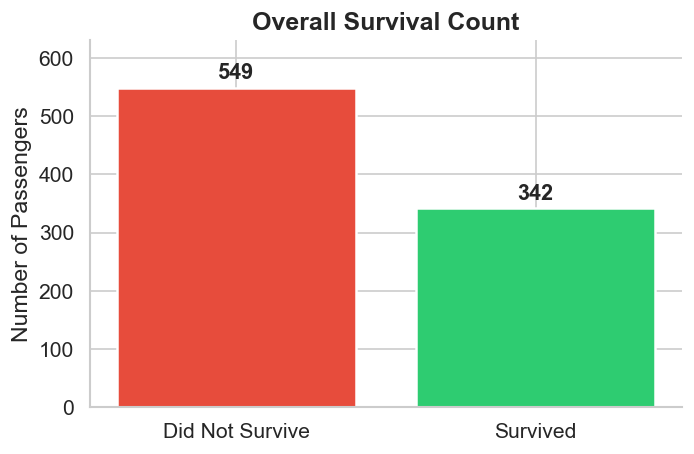

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71']
survived_counts = df['Survived'].value_counts()
bars = ax.bar(['Did Not Survive', 'Survived'], survived_counts.values, color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, survived_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_title('Overall Survival Count', fontsize=15)
ax.set_ylabel('Number of Passengers')
ax.set_ylim(0, survived_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

### 6.2  Bar Chart — Survival by Gender

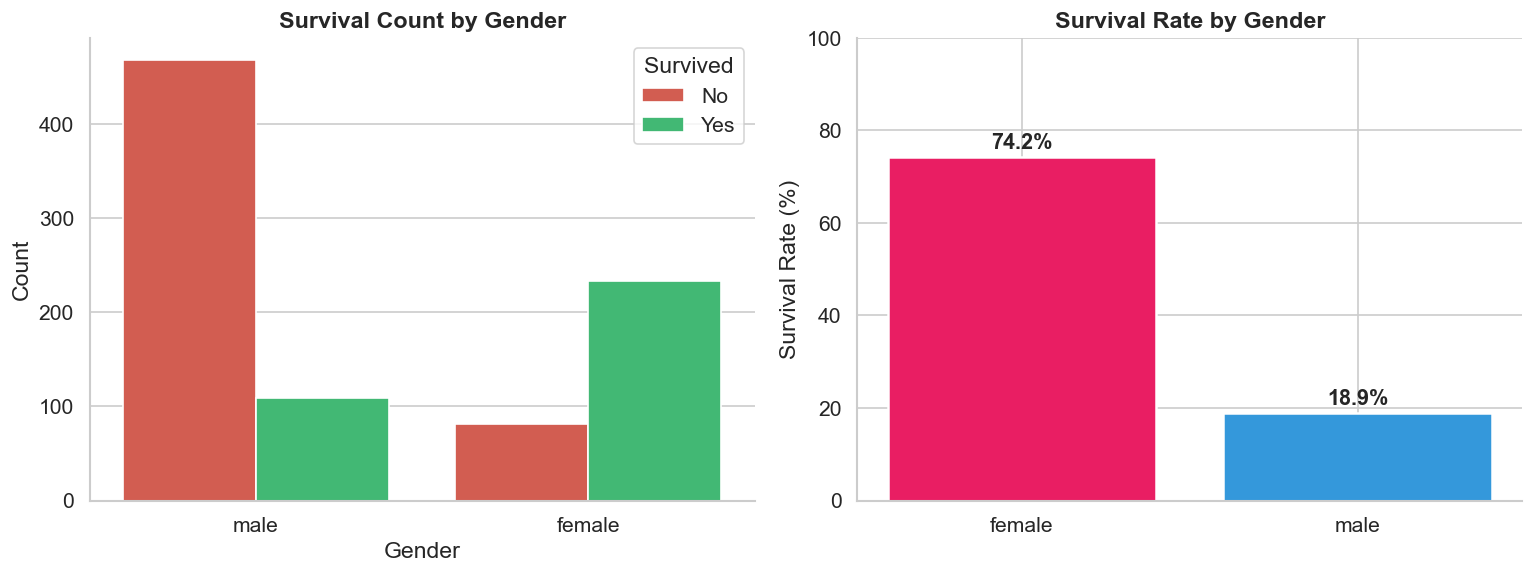

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Count plot
palette_gender = {'male': '#3498db', 'female': '#e91e63'}
ax1 = axes[0]
sns.countplot(data=df, x='Sex', hue='Survived', ax=ax1, palette=['#e74c3c', '#2ecc71'], edgecolor='white')
ax1.set_title('Survival Count by Gender', fontsize=14)
ax1.set_xlabel('Gender')
ax1.set_ylabel('Count')
ax1.legend(title='Survived', labels=['No', 'Yes'])

# Right: Survival rate bar
ax2 = axes[1]
rates = df.groupby('Sex')['Survived'].mean() * 100
bars = ax2.bar(rates.index, rates.values, color=[palette_gender[g] for g in rates.index],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, rates.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax2.set_title('Survival Rate by Gender', fontsize=14)
ax2.set_ylabel('Survival Rate (%)')
ax2.set_ylim(0, 100)

sns.despine()
plt.tight_layout()
plt.show()

### 6.3  Bar Chart — Survival by Passenger Class

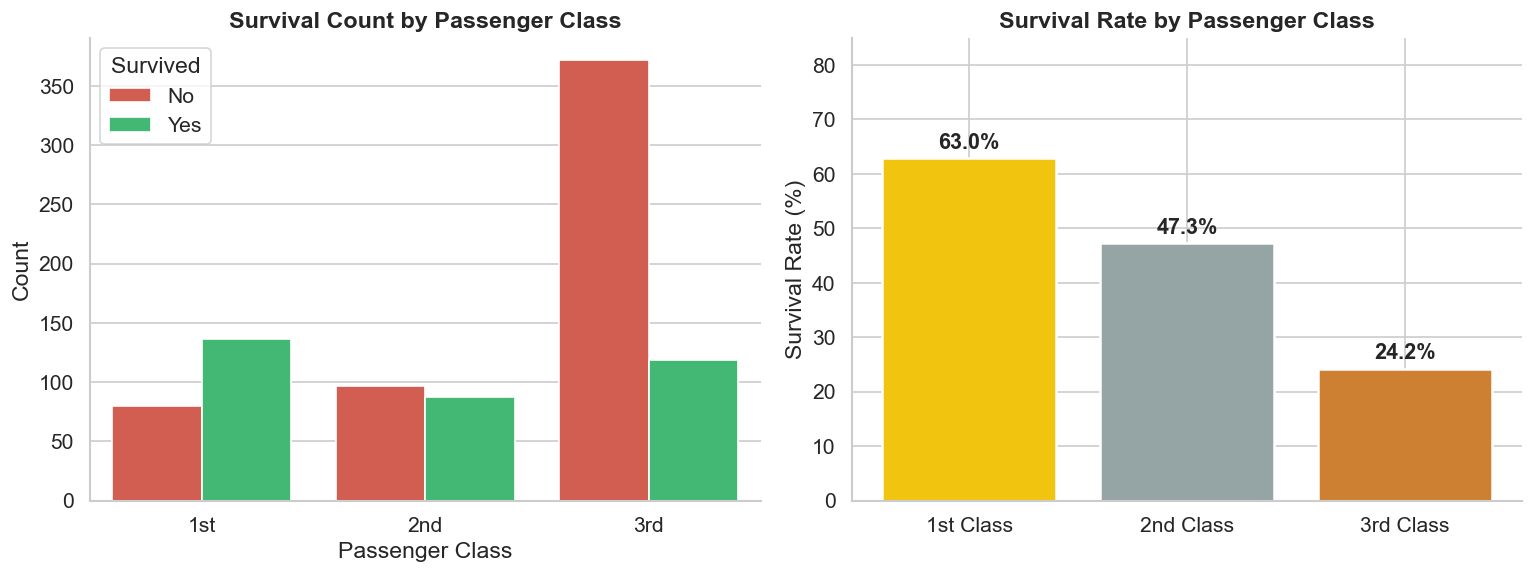

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Count plot
ax1 = axes[0]
sns.countplot(data=df, x='Pclass', hue='Survived', ax=ax1, palette=['#e74c3c', '#2ecc71'], edgecolor='white')
ax1.set_title('Survival Count by Passenger Class', fontsize=14)
ax1.set_xlabel('Passenger Class')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['1st', '2nd', '3rd'])
ax1.legend(title='Survived', labels=['No', 'Yes'])

# Right: Survival rate
ax2 = axes[1]
class_rates = df.groupby('Pclass')['Survived'].mean() * 100
class_colors = ['#f1c40f', '#95a5a6', '#cd7f32']
bars = ax2.bar(['1st Class', '2nd Class', '3rd Class'], class_rates.values,
               color=class_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, class_rates.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax2.set_title('Survival Rate by Passenger Class', fontsize=14)
ax2.set_ylabel('Survival Rate (%)')
ax2.set_ylim(0, 85)

sns.despine()
plt.tight_layout()
plt.show()

### 6.4  Histogram — Distribution of Passenger Ages

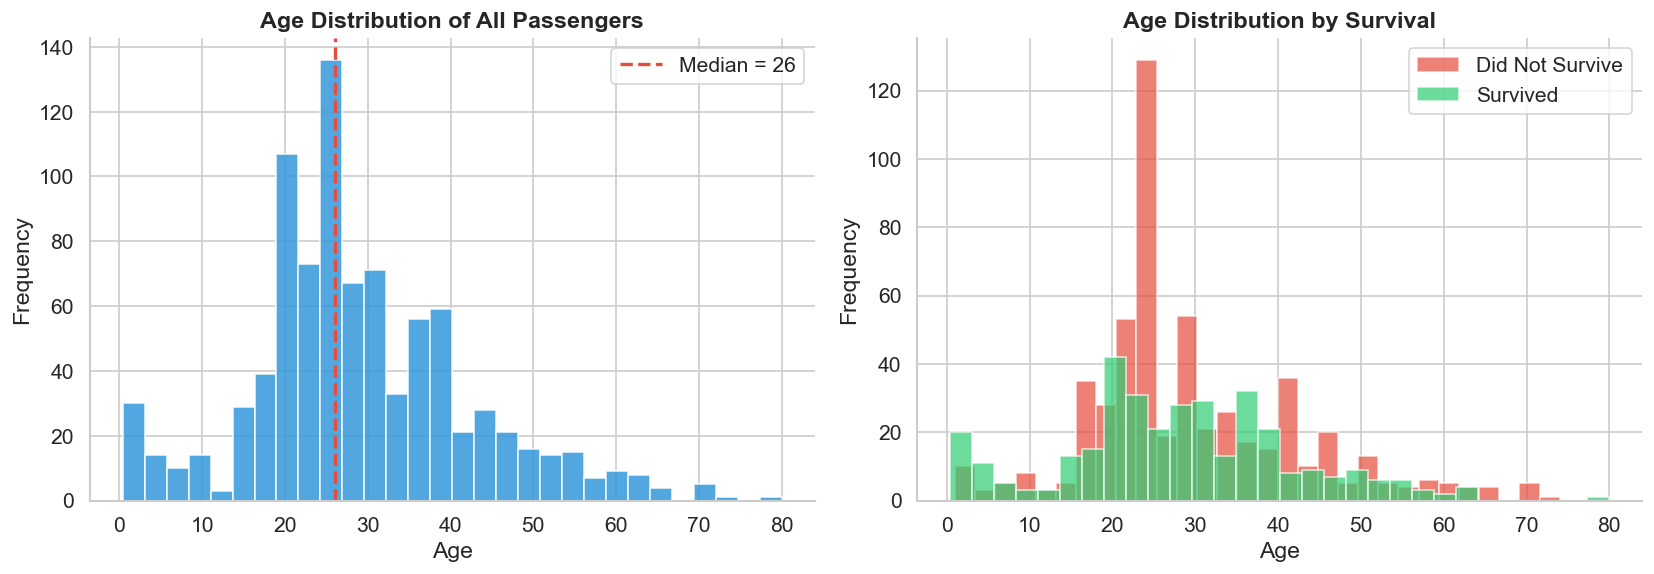

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overall age distribution
ax1 = axes[0]
ax1.hist(df['Age'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
ax1.axvline(df['Age'].median(), color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Median = {df["Age"].median():.0f}')
ax1.set_title('Age Distribution of All Passengers', fontsize=14)
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.legend()

# Right: Age distribution split by survival
ax2 = axes[1]
ax2.hist(df[df['Survived'] == 0]['Age'], bins=30, alpha=0.7, label='Did Not Survive',
         color='#e74c3c', edgecolor='white')
ax2.hist(df[df['Survived'] == 1]['Age'], bins=30, alpha=0.7, label='Survived',
         color='#2ecc71', edgecolor='white')
ax2.set_title('Age Distribution by Survival', fontsize=14)
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')
ax2.legend()

sns.despine()
plt.tight_layout()
plt.show()

### 6.5  Survival Rate by Age Group

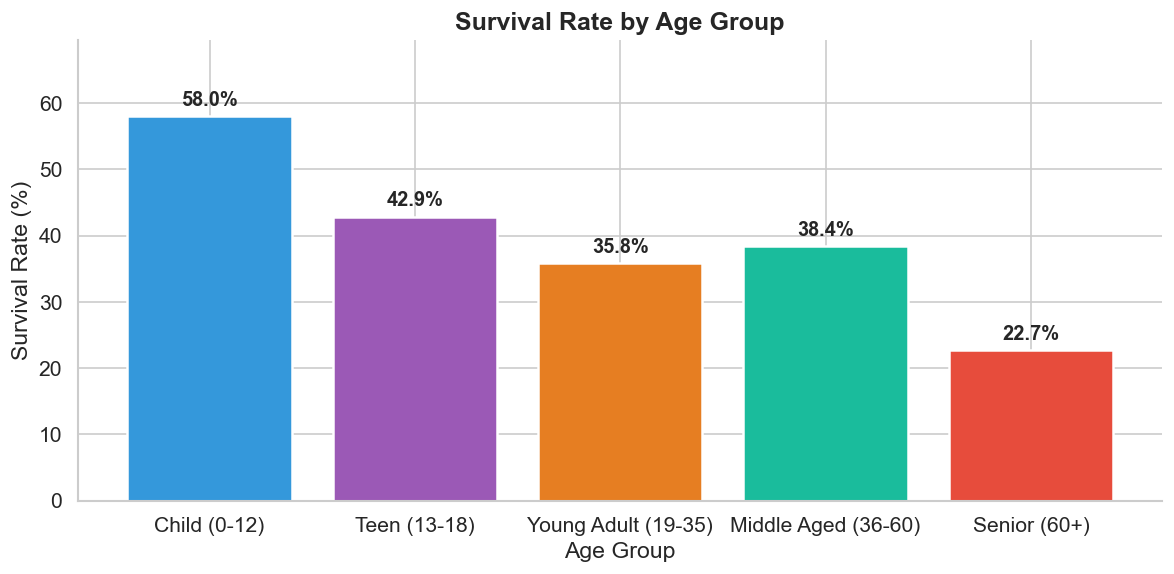

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
age_rates = df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100
colors_age = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c']
bars = ax.bar(age_rates.index.astype(str), age_rates.values, color=colors_age,
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, age_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Survival Rate by Age Group', fontsize=15)
ax.set_xlabel('Age Group')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, age_rates.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

### 6.6  Combined — Survival by Class & Gender (Heatmap)

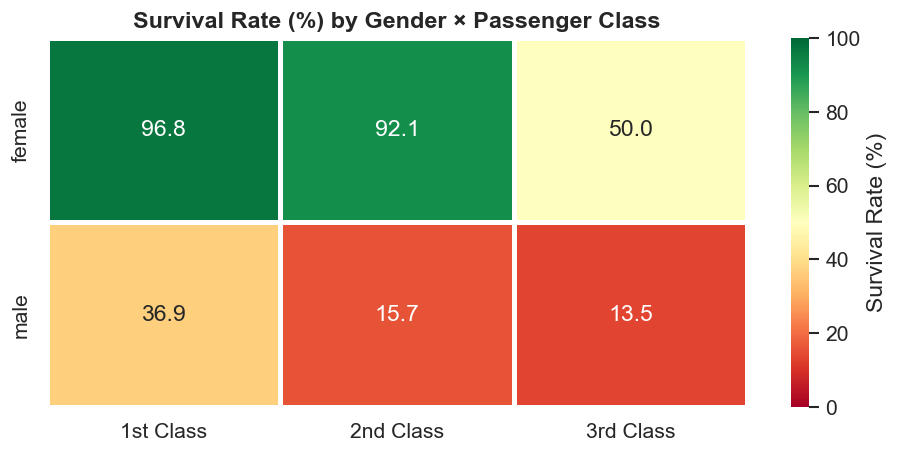

In [24]:
pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean') * 100
pivot.columns = ['1st Class', '2nd Class', '3rd Class']

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=2,
            linecolor='white', cbar_kws={'label': 'Survival Rate (%)'}, ax=ax,
            vmin=0, vmax=100)
ax.set_title('Survival Rate (%) by Gender × Passenger Class', fontsize=14)
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### 6.7  Fare Distribution by Class (Box Plot)

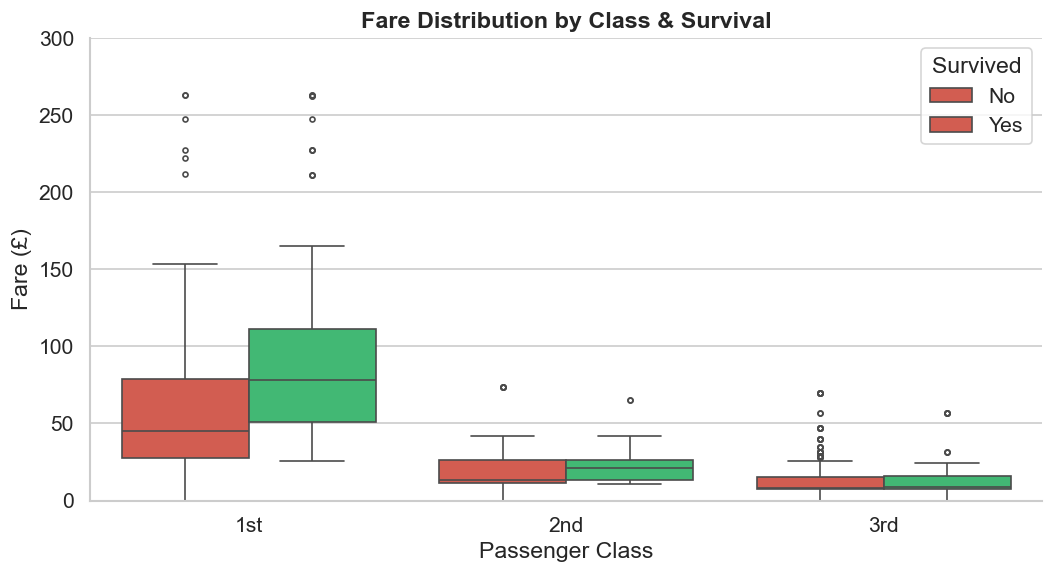

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Survived', palette=['#e74c3c', '#2ecc71'],
            ax=ax, fliersize=3)
ax.set_title('Fare Distribution by Class & Survival', fontsize=14)
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Fare (£)')
ax.set_xticklabels(['1st', '2nd', '3rd'])
ax.legend(title='Survived', labels=['No', 'Yes'])
ax.set_ylim(0, 300)
sns.despine()
plt.tight_layout()
plt.show()

### 6.8  Correlation Heatmap (Numerical Features)

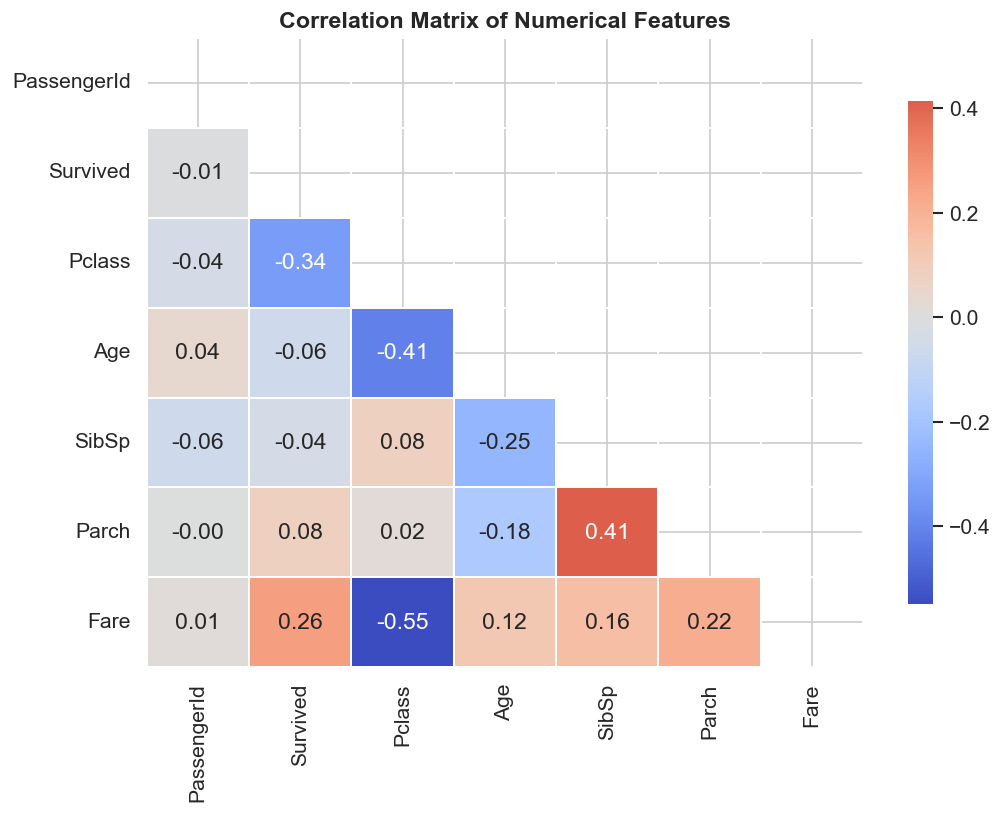

In [26]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=1, linecolor='white', center=0, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### 6.9  Embarkation Port vs. Survival

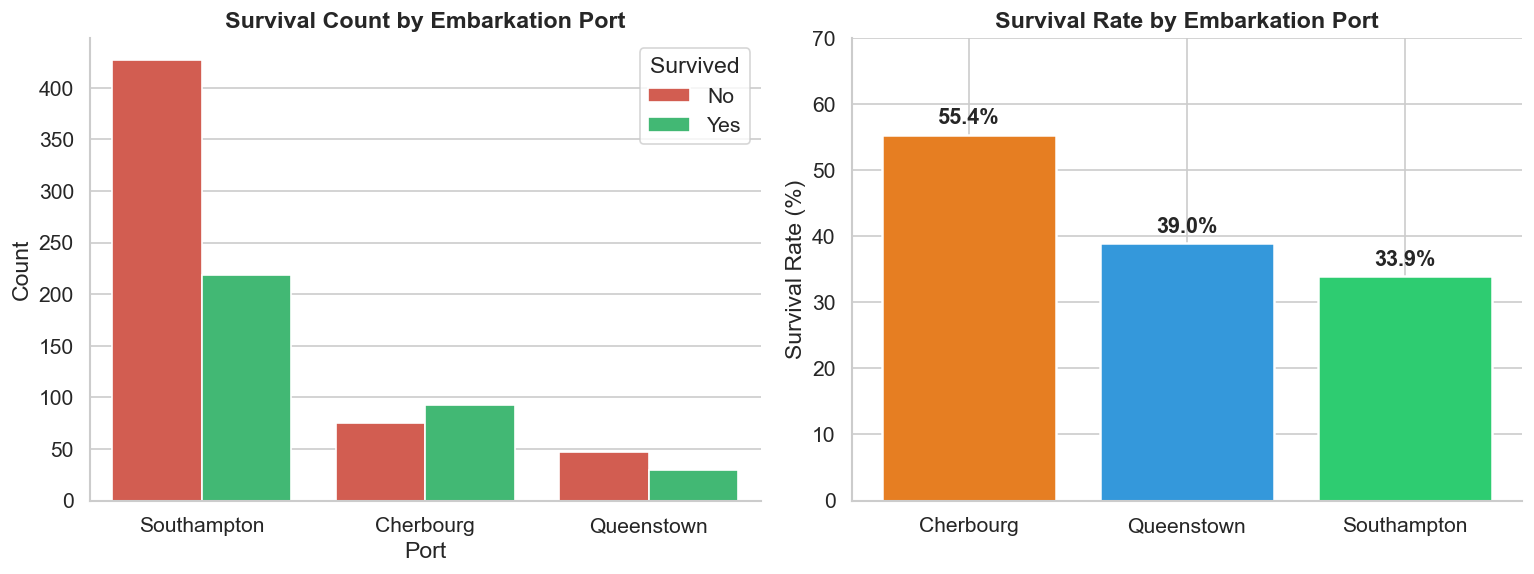

In [27]:
port_map = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
df['Port'] = df['Embarked'].map(port_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count
sns.countplot(data=df, x='Port', hue='Survived', ax=axes[0],
              palette=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Survival Count by Embarkation Port', fontsize=14)
axes[0].set_xlabel('Port')
axes[0].set_ylabel('Count')
axes[0].legend(title='Survived', labels=['No', 'Yes'])

# Rate
port_rates = df.groupby('Port')['Survived'].mean() * 100
bars = axes[1].bar(port_rates.index, port_rates.values,
                   color=['#e67e22', '#3498db', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, port_rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)
axes[1].set_title('Survival Rate by Embarkation Port', fontsize=14)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 70)

sns.despine()
plt.tight_layout()
plt.show()

# Clean up helper column
df = df.drop(columns=['Port'])

---
## 7. Summary of Key Findings

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Gender was the strongest survival factor** | ~74 % of females survived vs. ~19 % of males |
| 2 | **Passenger class mattered significantly** | 1st-class passengers had ~63 % survival vs. ~24 % for 3rd-class |
| 3 | **Children had the best survival rate** | The 0-12 age group had the highest survival rate among all age brackets |
| 4 | **Higher fare ≈ higher survival** | Fare correlates with class, and both correlate with survival |
| 5 | **Cherbourg passengers survived more** | Likely because a larger proportion of 1st-class passengers embarked there |

###  Overall Takeaway
Survival on the Titanic was **not random** — it was heavily influenced by **gender**, **class**, and **age**.  
The "women and children first" evacuation policy is clearly reflected in the data.